# DINOv3 Mask Alignment

Qualitative evaluation of DINOv3-based candidate mask filtering for SAM3 agent acceleration.

**Goal**: Given a source object crop (from the GT mask), measure cosine distance to each SAM3 candidate crop on the destination frame. Visualise which candidates survive a threshold and whether the GT-matching candidate is preserved.

**Pipeline context**: This is Step 1 of 3 — qualitative exploration only.  
If cosine distance reliably ranks the correct candidate closer to the source, the filter is integrated into `agent_core.py` (Step 2), then evaluated at scale (Step 3).

**No MLLM required** for Sections 1–9. Section 10 (optional agent run) requires Ollama and can be skipped.

## 1. Set up and Helper Functions

In [52]:
import gc
import json
import os
import random
import shutil
import tempfile
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image
import math
from pycocotools import mask as mask_util

In [2]:
if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.autocast("mps", dtype=torch.bfloat16).__enter__()
elif torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [55]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def decode_mask(rle_str: str, H: int, W: int) -> np.ndarray:
    """RLE string -> bool array at (H, W)."""
    rle = {"size": [H, W], "counts": rle_str}
    return mask_util.decode(rle).astype(bool)


def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    """Pixel-level IoU between two bool arrays (auto-resizes pred to gt shape)."""
    if pred.shape != gt.shape:
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (gt.shape[1], gt.shape[0]), Image.NEAREST
            )
        ) > 127
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else 0.0


def mask_bbox_square(mask: np.ndarray) -> tuple[int, int, int, int]:
    """Return (x1, y1, x2, y2) square bbox centered on mask, clamped to image bounds."""
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    y1 = int(np.argmax(rows))
    y2 = int(len(rows) - 1 - np.argmax(rows[::-1]))
    x1 = int(np.argmax(cols))
    x2 = int(len(cols) - 1 - np.argmax(cols[::-1]))
    H, W = mask.shape
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    half = max(x2 - x1, y2 - y1) // 2
    x1 = max(0, cx - half)
    x2 = min(W - 1, cx + half)
    y1 = max(0, cy - half)
    y2 = min(H - 1, cy + half)
    return x1, y1, x2, y2


def snap_to_patch_grid(v: int, patch: int = 16) -> int:
    return max(patch, int(math.ceil(v / patch) * patch))

def make_dino_crop(rgb: np.ndarray, mask: np.ndarray, patch: int = 16) -> np.ndarray:
    """
    Create a square crop for DINO such that:
      1. the full mask is included,
      2. the masked object is as centered as possible,
      3. overlapping crops across nearby objects are allowed,
      4. no mask pixels are cut off unless the mask/image is degenerate.

    Returns a uint8 HxWx3 square crop whose side is snapped to `patch`.
    """
    H, W = rgb.shape[:2]

    if mask is None or mask.size == 0 or not mask.any():
        return np.zeros((patch, patch, 3), dtype=np.uint8)

    ys, xs = np.where(mask)
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    # bbox sizes are inclusive in pixel support, so add 1
    box_w = x_max - x_min + 1
    box_h = y_max - y_min + 1

    # object center from mask support
    cx = (x_min + x_max) / 2.0
    cy = (y_min + y_max) / 2.0

    # minimal square side that fully contains the mask bbox
    side = snap_to_patch_grid(max(box_w, box_h), patch=patch)

    # Try to center the crop on the object center
    x1 = int(round(cx - side / 2.0))
    y1 = int(round(cy - side / 2.0))
    x2 = x1 + side
    y2 = y1 + side

    # Shift to remain inside image bounds
    if x1 < 0:
        x2 -= x1
        x1 = 0
    if y1 < 0:
        y2 -= y1
        y1 = 0
    if x2 > W:
        x1 -= (x2 - W)
        x2 = W
    if y2 > H:
        y1 -= (y2 - H)
        y2 = H

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    # If the shifted crop still does not fully contain the mask bbox
    # (can happen near boundaries or due to snapping/rounding),
    # enlarge the square until it does, up to the full image extent.
    def contains_mask(_x1, _y1, _x2, _y2):
        return (_x1 <= x_min) and (_y1 <= y_min) and (_x2 > x_max) and (_y2 > y_max)

    max_side = snap_to_patch_grid(max(H, W), patch=patch)

    while not contains_mask(x1, y1, x2, y2):
        new_side = min(max_side, side + patch)
        if new_side == side:
            break
        side = new_side

        x1 = int(round(cx - side / 2.0))
        y1 = int(round(cy - side / 2.0))
        x2 = x1 + side
        y2 = y1 + side

        if x1 < 0:
            x2 -= x1
            x1 = 0
        if y1 < 0:
            y2 -= y1
            y1 = 0
        if x2 > W:
            x1 -= (x2 - W)
            x2 = W
        if y2 > H:
            y1 -= (y2 - H)
            y2 = H

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(W, x2)
        y2 = min(H, y2)

    crop = rgb[y1:y2, x1:x2]

    if crop.shape[0] == 0 or crop.shape[1] == 0:
        return np.zeros((patch, patch, 3), dtype=np.uint8)

    # Pad to square if the image boundary prevented a perfect square crop.
    ch, cw = crop.shape[:2]
    final_side = max(ch, cw)

    if ch != cw:
        pad_top = (final_side - ch) // 2
        pad_bottom = final_side - ch - pad_top
        pad_left = (final_side - cw) // 2
        pad_right = final_side - cw - pad_left

        crop = np.pad(
            crop,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
            mode="constant",
            constant_values=0,
        )

    # Final safety: keep size on patch grid
    out_side = snap_to_patch_grid(crop.shape[0], patch=patch)
    if crop.shape[0] != out_side:
        padded = np.zeros((out_side, out_side, 3), dtype=np.uint8)
        off_y = (out_side - crop.shape[0]) // 2
        off_x = (out_side - crop.shape[1]) // 2
        padded[off_y:off_y + crop.shape[0], off_x:off_x + crop.shape[1]] = crop
        crop = padded

    return crop.astype(np.uint8)


def embed_crop(crop: np.ndarray, dino_model: torch.nn.Module, device: torch.device) -> np.ndarray:
    """Run DINOv3 on crop, return unit-norm CLS token embedding as float32 array."""
    t = TF.to_tensor(Image.fromarray(crop).convert("RGB"))
    t = TF.normalize(t, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    with torch.inference_mode():
        feats = dino_model.get_intermediate_layers(
            t.unsqueeze(0).to(device),
            n=1,
            return_class_token=True,
            norm=True,
        )
        cls = feats[0][1][0]
    emb = cls.float().cpu().numpy()
    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine distance (1 - cosine_similarity) between two unit-norm vectors. Range [0, 2]."""
    return float(1.0 - np.dot(a, b))


def render_overlay(rgb: np.ndarray, pred: np.ndarray, gt: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """Blend pred (red), GT (green), overlap (yellow) onto an RGB frame copy."""
    if pred.shape != gt.shape:
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (gt.shape[1], gt.shape[0]), Image.NEAREST
            )
        ) > 127
    img = rgb.copy().astype(np.float32)
    overlap   = pred & gt
    pred_only = pred & ~overlap
    gt_only   = gt   & ~overlap
    for mask, colour in [
        (gt_only,   np.array([0,   200,   0], dtype=np.float32)),
        (pred_only, np.array([220,   0,   0], dtype=np.float32)),
        (overlap,   np.array([255, 220,   0], dtype=np.float32)),
    ]:
        img[mask] = img[mask] * (1 - alpha) + colour * alpha
    return img.clip(0, 255).astype(np.uint8)


def render_candidate_grid(
    src_rgb: np.ndarray,
    src_gt_mask: np.ndarray,
    dst_rgb: np.ndarray,
    cand_masks: list,
    cand_scores: list,
    distances: list,
    gt_ious: list,
    threshold: float,
) -> plt.Figure:
    """
    First subplot: source GT mask (overlay).
    Then one subplot per candidate crop.
    """
    n = len(cand_masks)
    total = n + 1  # +1 for source

    fig, axes = plt.subplots(1, total, figsize=(4 * total, 4))
    if total == 1:
        axes = [axes]

    # --- Source GT panel ---
    src_crop = make_dino_crop(src_rgb, src_gt_mask)
    axes[0].imshow(src_crop)
    axes[0].set_title("SOURCE (DINO crop)", fontsize=10)
    # src_vis = _overlay_mask(src_rgb, src_gt_mask, color=(255, 0, 0), alpha=0.45)
    # axes[0].imshow(src_vis)
    # axes[0].set_title("SOURCE (GT mask)", fontsize=10)
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    for spine in axes[0].spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(2)

    # --- Candidate panels ---
    for i, (mask, score, dist, iou) in enumerate(zip(cand_masks, cand_scores, distances, gt_ious)):
        kept = dist <= threshold
        crop = make_dino_crop(dst_rgb, mask) if mask.any() else np.zeros((64, 64, 3), dtype=np.uint8)

        ax = axes[i + 1]
        ax.imshow(crop)
        ax.set_title(
            f"#{i}  score={score:.2f}\ndist={dist:.3f}  iou={iou:.3f}\n{'KEEP' if kept else 'DROP'}",
            fontsize=9,
            color="green" if kept else "tomato",
        )

        for spine in ax.spines.values():
            spine.set_edgecolor("green" if kept else "tomato")
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"Candidate crops  (threshold = {threshold:.3f})", y=1.02)
    plt.tight_layout()
    return fig

def plot_sample(
    src_rgb: np.ndarray,
    src_gt_mask: np.ndarray,
    dst_rgb: np.ndarray,
    dst_gt_mask: np.ndarray,
    cand_masks: list,
    distances: list,
    gt_ious: list,
    threshold: float,
    take_uid: str,
    obj_name: str,
    src_frame: str,
    dst_frame: str,
) -> plt.Figure:
    """3-col figure: source GT crop highlight | all candidates on dst | kept + GT overlay."""
    kept_idx = [i for i, d in enumerate(distances) if d <= threshold]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Col 1: source frame + GT overlay + crop bbox rectangle
    axes[0].imshow(render_overlay(src_rgb, src_gt_mask, src_gt_mask))
    x1, y1, x2, y2 = mask_bbox_square(src_gt_mask)
    axes[0].add_patch(plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="white", facecolor="none", linestyle="--",
    ))
    axes[0].set_title(f"Source -- GT crop\nframe {src_frame}")
    axes[0].axis("off")

    # Col 2: destination frame + all candidates labelled
    overlay_all = dst_rgb.copy().astype(np.float32)
    colour_all  = np.array([0, 120, 220], dtype=np.float32)
    for mask in cand_masks:
        overlay_all[mask] = overlay_all[mask] * 0.55 + colour_all * 0.45
    axes[1].imshow(overlay_all.clip(0, 255).astype(np.uint8))
    for i, (mask, dist, iou) in enumerate(zip(cand_masks, distances, gt_ious)):
        if mask.any():
            ys, xs = np.where(mask)
            axes[1].text(
                xs.mean(), ys.mean(),
                f"#{i}\nd={dist:.2f}\niou={iou:.2f}",
                color="white", fontsize=7, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.5),
            )
    axes[1].set_title(f"All {len(cand_masks)} candidates\nframe {dst_frame}")
    axes[1].axis("off")

    # Col 3: kept candidates union + GT overlay
    kept_union = np.zeros(dst_gt_mask.shape, dtype=bool)
    for i in kept_idx:
        kept_union |= cand_masks[i]
    axes[2].imshow(render_overlay(dst_rgb, kept_union, dst_gt_mask))
    axes[2].legend(
        handles=[
            mpatches.Patch(color=(0, 200/255, 0),  label="GT only"),
            mpatches.Patch(color=(220/255, 0, 0),  label="Kept pred"),
            mpatches.Patch(color=(1.0, 220/255, 0), label="Overlap"),
        ],
        loc="lower right", fontsize=8,
    )
    axes[2].set_title(
        f"Kept ({len(kept_idx)}/{len(cand_masks)}) + GT\nthreshold = {threshold:.3f}"
    )
    axes[2].axis("off")

    fig.suptitle(
        f"{take_uid}  |  {obj_name}  |  {src_frame} -> {dst_frame}",
        y=1.01, fontsize=11,
    )
    plt.tight_layout()
    return fig

## 2. Configuration

Run the three sub-steps in order.  
Each step prints information that guides the choices in the next step.

### 2.1 — Data paths

In [4]:
# -- Step 2.1: Data paths -----------------------------------------------------
DATA_DIR   = "../data/dev"   # <- root containing {take_uid}/{camera}/{frame}.jpg
DINOV3_DIR = "../dinov3-main"    # <- absolute path to local dinov3-main repo

assert os.path.isdir(DATA_DIR),   f"DATA_DIR not found: {DATA_DIR}"
assert os.path.isdir(DINOV3_DIR), f"DINOV3_DIR not found: {DINOV3_DIR}"

rows = []
for take_uid in sorted(os.listdir(DATA_DIR)):
    ann_path = os.path.join(DATA_DIR, take_uid, "annotation.json")
    if not os.path.isfile(ann_path):
        continue
    with open(ann_path) as f:
        ann = json.load(f)
    for obj_name, cams in ann.get("masks", {}).items():
        for cam, frames in cams.items():
            rows.append((take_uid, obj_name, cam, len(frames)))

print(f"{'Take':<30}  {'Object':<30}  {'Camera':<25}  {'Frames':>6}")
print("\u2500" * 98)
for take, obj, cam, n in rows:
    print(f"{take:<30}  {obj:<30}  {cam:<25}  {n:>6}")
print(f"\n{len(rows)} (take, object, camera) combinations found.")
print("-> Set N_SAMPLES, RANDOM_SEED, DIRECTION in the next cell.")

Take                            Object                          Camera                     Frames
──────────────────────────────────────────────────────────────────────────────────────────────────
0efd9fc1-0f49-403d-9252-93f119a3ea3c  black_handle_knife_0            gp01                          345
0efd9fc1-0f49-403d-9252-93f119a3ea3c  black_handle_knife_0            aria01_214-1                  127
0efd9fc1-0f49-403d-9252-93f119a3ea3c  stainless_spoon_0               aria01_214-1                  144
0efd9fc1-0f49-403d-9252-93f119a3ea3c  stainless_spoon_0               gp04                          287
0efd9fc1-0f49-403d-9252-93f119a3ea3c  black_tea_package_0             gp04                           11
0efd9fc1-0f49-403d-9252-93f119a3ea3c  black_tea_package_0             aria01_214-1                   37
0efd9fc1-0f49-403d-9252-93f119a3ea3c  white_bowl_0                    aria01_214-1                  175
0efd9fc1-0f49-403d-9252-93f119a3ea3c  white_bowl_0                    gp01 

### 2.2 — Sampling

In [33]:
N_SAMPLES   = 4          # <- number of random (take, object, src_frame, dst_frame) pairs
RANDOM_SEED = 7         # <- for reproducibility
DIRECTION   = "exo->ego" # <- "ego->exo" | "exo->ego" | "both"

#     Take                        Object                      Dir        Src cam                   Frm  Dst cam                   Frm
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
0     8acb2112-465c-4088-b502-65fd9704dd77  black saucepan _0           exo→ego    gp03                    13860  aria01_214-1            13860
1     0efd9fc1-0f49-403d-9252-93f119a3ea3c  blue_chopping_board_0       exo→ego    gp03                     7110  aria01_214-1             7110
2     8acb2112-465c-4088-b502-65fd9704dd77  glass mug_0                 exo→ego    gp04                     6930  aria01_214-1             6930
3     8acb2112-465c-4088-b502-65fd9704dd77  oyster sauce bottle_0       exo→ego    gp03                    18930  aria01_214-1            18930

-> Fill in OBJECT_DESCRIPTIONS in the next cell (one entry per row above).


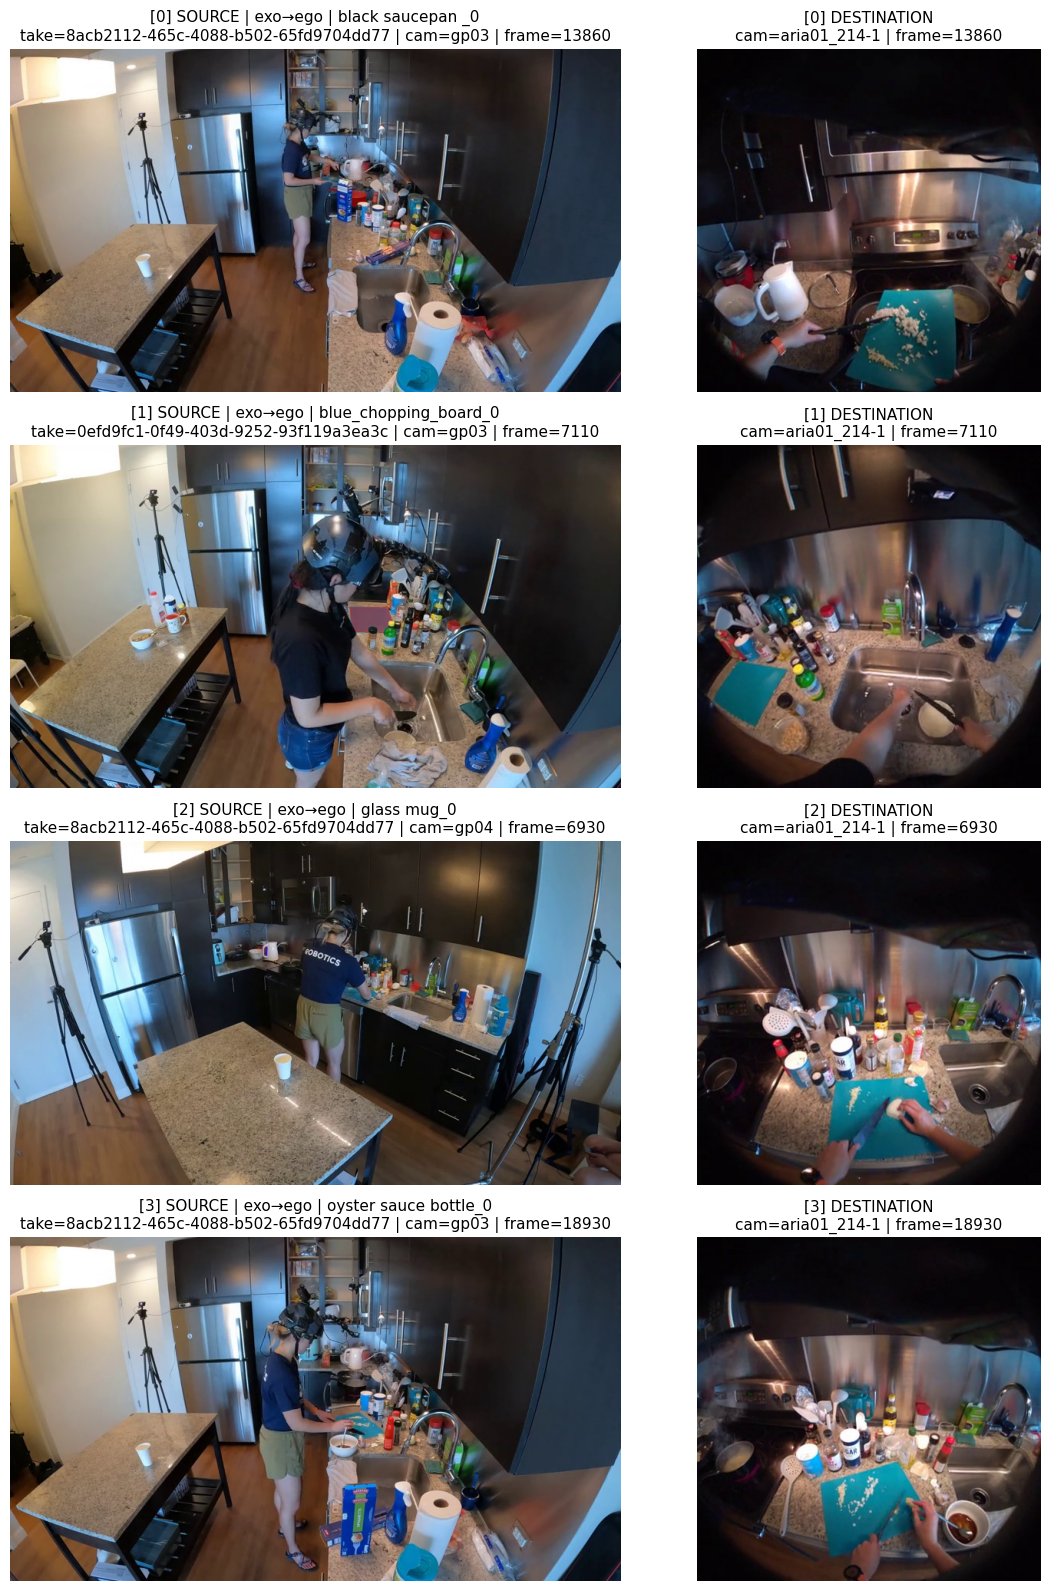

In [34]:
assert DIRECTION in ("ego->exo", "exo->ego", "both"), \
    f"DIRECTION must be 'ego->exo', 'exo->ego', or 'both', got '{DIRECTION}'"

rng = random.Random(RANDOM_SEED)

# Build pool of valid (take, obj, src_cam, dst_cam, frame, ann) tuples
# where the SAME frame number is annotated in both source and destination views.
pool = []
for take_uid in sorted(os.listdir(DATA_DIR)):
    ann_path = os.path.join(DATA_DIR, take_uid, "annotation.json")
    if not os.path.isfile(ann_path):
        continue

    with open(ann_path) as f:
        ann = json.load(f)

    for obj_name, cams in ann.get("masks", {}).items():
        cam_list = list(cams.keys())
        ego_cams = [c for c in cam_list if "aria" in c.lower()]
        exo_cams = [c for c in cam_list if "aria" not in c.lower()]

        if DIRECTION == "ego->exo":
            pairs = [(e, x) for e in ego_cams for x in exo_cams]
        elif DIRECTION == "exo->ego":
            pairs = [(x, e) for x in exo_cams for e in ego_cams]
        else:
            pairs = [(e, x) for e in ego_cams for x in exo_cams] + \
                    [(x, e) for x in exo_cams for e in ego_cams]

        for src_cam, dst_cam in pairs:
            src_frames = set(cams[src_cam].keys())
            dst_frames = set(cams[dst_cam].keys())

            # Only keep frames that exist in both views
            shared_frames = sorted(src_frames & dst_frames, key=int)

            for frame in shared_frames:
                pool.append((take_uid, obj_name, src_cam, dst_cam, frame, ann))

assert pool, "No valid ego/exo pairs with shared frame numbers found -- check DATA_DIR and annotation.json structure."
assert N_SAMPLES <= len(pool), \
    f"N_SAMPLES={N_SAMPLES} exceeds available shared-frame pairs ({len(pool)}). Reduce N_SAMPLES."

selected_pool = rng.sample(pool, N_SAMPLES)

# Resolve source frame deterministically from sampled shared frame.
# Destination frame must be the same frame number.
samples = []
for take_uid, obj_name, src_cam, dst_cam, frame, ann in selected_pool:
    src_frame = frame
    dst_frame = frame
    direction = "ego\u2192exo" if "aria" in src_cam.lower() else "exo\u2192ego"

    samples.append({
        "take_uid":  take_uid,
        "obj_name":  obj_name,
        "src_cam":   src_cam,
        "src_frame": src_frame,
        "dst_cam":   dst_cam,
        "dst_frame": dst_frame,
        "direction": direction,
        "ann":       ann,
    })

print(f"{'#':<4}  {'Take':<26}  {'Object':<26}  {'Dir':<9}  {'Src cam':<22}  {'Frm':>5}  {'Dst cam':<22}  {'Frm':>5}")
print("\u2500" * 130)
for i, s in enumerate(samples):
    print(f"{i:<4}  {s['take_uid']:<26}  {s['obj_name']:<26}  {s['direction']:<9}  "
          f"{s['src_cam']:<22}  {s['src_frame']:>5}  {s['dst_cam']:<22}  {s['dst_frame']:>5}")
print(f"\n-> Fill in OBJECT_DESCRIPTIONS in the next cell (one entry per row above).")

def _load_rgb(img_path):
    return np.array(Image.open(img_path).convert("RGB"))

def _get_src_mask(sample):
    ann = sample["ann"]
    obj_name = sample["obj_name"]
    src_cam = sample["src_cam"]
    src_frame = str(sample["src_frame"])

    address = ann["masks"][obj_name][src_cam][src_frame]
    H = address["size"][0]
    W = address["size"][1]
    m = decode_mask(address["counts"], H, W).astype(bool)

    return m

def _overlay_mask(img, mask, color=(255, 0, 0), alpha=0.45):
    out = img.copy().astype(np.float32)

    if mask.shape[:2] != img.shape[:2]:
        mask = np.array(
            Image.fromarray(mask.astype(np.uint8)).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST
            )
        ).astype(bool)

    color = np.array(color, dtype=np.float32)
    out[mask] = (1 - alpha) * out[mask] + alpha * color
    return out.astype(np.uint8)

n = len(samples)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 4 * n))

if n == 1:
    axes = np.array([axes])  # make it indexable as axes[i, j]

for i, s in enumerate(samples):
    src_path = os.path.join(DATA_DIR, s["take_uid"], s["src_cam"], f"{s['src_frame']}.jpg")
    dst_path = os.path.join(DATA_DIR, s["take_uid"], s["dst_cam"], f"{s['dst_frame']}.jpg")

    assert os.path.isfile(src_path), f"Missing source image: {src_path}"
    assert os.path.isfile(dst_path), f"Missing destination image: {dst_path}"

    src_img = _load_rgb(src_path)
    dst_img = _load_rgb(dst_path)

    src_mask = _get_src_mask(s)
    src_vis = _overlay_mask(src_img, src_mask, color=(255, 0, 0), alpha=0.45)

    # Left: source image with GT mask overlay
    axes[i, 0].imshow(src_vis)
    axes[i, 0].set_title(
        f"[{i}] SOURCE | {s['direction']} | {s['obj_name']}\n"
        f"take={s['take_uid']} | cam={s['src_cam']} | frame={s['src_frame']}"
    )
    axes[i, 0].axis("off")

    # Right: destination image
    axes[i, 1].imshow(dst_img)
    axes[i, 1].set_title(
        f"[{i}] DESTINATION\n"
        f"cam={s['dst_cam']} | frame={s['dst_frame']}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### 2.3 — Object descriptions

Read the table above and write a short description for each sampled object instance.  
This will be used as the SAM3 text prompt for candidate generation on the **destination** frame.

In [42]:
# -- Step 2.3: Object descriptions --------------------------------------------
# Fill in a description for every sample listed above.
OBJECT_DESCRIPTIONS = {
    0: "black cooking pan on stove",
    1: 'blue cutting board on table',
    2: 'glass mug',
    3: 'small plastic bottle'   # <- describe the object as it appears in the source frame
    # add one entry per sample
}

assert set(OBJECT_DESCRIPTIONS.keys()) == set(range(N_SAMPLES)), (
    f"OBJECT_DESCRIPTIONS must have keys 0..{N_SAMPLES - 1}. "
    f"Got: {sorted(OBJECT_DESCRIPTIONS.keys())}"
)
assert all(v.strip() not in ("", "...") for v in OBJECT_DESCRIPTIONS.values()), \
    "Replace all '...' placeholders with actual descriptions before proceeding."
print("\u2713 Object descriptions confirmed for all samples.")

✓ Object descriptions confirmed for all samples.


### 2.4 — Filtering parameters

In [45]:
# -- Step 2.4: Filtering parameters -------------------------------------------
COSINE_THRESHOLD = 0.80         # <- cosine distance cutoff (0-2; typical 0-1)
DINO_MODEL_NAME  = "dinov3_vits16"  # <- model name for torch.hub.load from DINOV3_DIR
VIS_STRIDE       = 1            # <- show every Nth sample in visualisation loop

print(f"  COSINE_THRESHOLD : {COSINE_THRESHOLD}  (cosine dist = 1 - cos_sim, range 0-2)")
print(f"  DINO_MODEL_NAME  : {DINO_MODEL_NAME}")
print(f"  VIS_STRIDE       : {VIS_STRIDE}")
print("\n-> Run the next cell to load models.")

  COSINE_THRESHOLD : 0.8  (cosine dist = 1 - cos_sim, range 0-2)
  DINO_MODEL_NAME  : dinov3_vits16
  VIS_STRIDE       : 1

-> Run the next cell to load models.


## 3. Model Loading

In [46]:
import sys, os
from pathlib import Path
from functools import partial

sys.path.insert(0, str(Path(DINOV3_DIR).resolve()))
DINOV3_DIR = str(Path(DINOV3_DIR).resolve())

# --- DINOv3 ------------------------------------------------------------
# Map model name -> local checkpoint path
DINO_LOCAL_WEIGHTS = {
    "dinov3_vits16": os.path.join(DINOV3_DIR, "dinov3_vits16_pretrain_lvd1689m-08c60483.pth"),
    # add others here if needed:
    # "dinov3_vitb16": os.path.join(DINOV3_DIR, "dinov3_vitb16_pretrain_lvd1689m-....pth"),
    # "dinov3_vitl16": os.path.join(DINOV3_DIR, "dinov3_vitl16_pretrain_lvd1689m-....pth"),
}

assert DINO_MODEL_NAME in DINO_LOCAL_WEIGHTS, \
    f"No local checkpoint registered for model '{DINO_MODEL_NAME}'"

DINO_WEIGHTS = DINO_LOCAL_WEIGHTS[DINO_MODEL_NAME]
assert os.path.isfile(DINO_WEIGHTS), f"Missing checkpoint: {DINO_WEIGHTS}"

print(f"Loading DINOv3 '{DINO_MODEL_NAME}' from {DINOV3_DIR} ...")
print(f"  using local checkpoint: {DINO_WEIGHTS}")

dino_model = torch.hub.load(
    repo_or_dir=DINOV3_DIR,
    model=DINO_MODEL_NAME,
    source="local",
    weights=DINO_WEIGHTS,
)
dino_model.eval().to(device)
print(f"  DINOv3 ready on {device}.")

# --- SAM3 --------------------------------------------------------------
import os
import sys
from pathlib import Path

# notebook location
NOTEBOOK_DIR = Path.cwd()

# adjust if needed: this should point to the directory that CONTAINS the sam3 package folder
SAM3_PARENT_DIR = (NOTEBOOK_DIR / "..").resolve()

sys.path.insert(0, str(SAM3_PARENT_DIR))

import sam3 as _sam3_pkg
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.agent.client_sam3 import call_sam_service as _call_sam_service_orig
from functools import partial

_bpe_path = os.path.join(os.path.dirname(_sam3_pkg.__file__), "assets", "bpe_simple_vocab_16e6.txt.gz")
print("Loading SAM3 image model ...")
_sam3_model = build_sam3_image_model(bpe_path=_bpe_path, device=str(device))
sam3_processor = Sam3Processor(_sam3_model, confidence_threshold=0.5, device=str(device))
call_sam_service_base = partial(_call_sam_service_orig, sam3_processor=sam3_processor)
print(f"  SAM3 ready on {device}.")
print("\nAll models loaded. Run the next cell to process samples.")

Loading DINOv3 'dinov3_vits16' from /Users/marcolomele/Documents/Repos/sam3/dinov3-main ...
  using local checkpoint: /Users/marcolomele/Documents/Repos/sam3/dinov3-main/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
  DINOv3 ready on mps.
Loading SAM3 image model ...
  SAM3 ready on mps.

All models loaded. Run the next cell to process samples.


## 4. Candidate Generation and DINOv3 Ranking

For each sample:
1. Generate SAM3 candidates on the **destination** frame using `call_sam_service_base` (SAM3 image model only, no MLLM).
2. Embed the **source GT mask crop** with DINOv3 -> `src_emb`.
3. Embed each **candidate crop** -> compute cosine distance to `src_emb`.
4. Compute GT IoU for each candidate.
5. Apply the threshold filter.

In [53]:
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["figure.titlesize"] = 11

_tmp_dir = tempfile.mkdtemp(prefix="dino_align_")
results  = []

def _load_gt(mask_entry, H_img, W_img):
    """
    mask_entry can be either:
    - a dict like {"size": [H, W], "counts": ...}
    - a raw RLE counts string/bytes
    Returns a boolean mask resized to (H_img, W_img).
    """
    if mask_entry is None:
        return np.zeros((H_img, W_img), dtype=bool)

    if isinstance(mask_entry, dict):
        H0, W0 = mask_entry["size"]
        counts = mask_entry["counts"]
        m = decode_mask(counts, H0, W0)
    else:
        # fallback for raw RLE counts only
        m = decode_mask(mask_entry, 1408, 1408)

    if m.shape != (H_img, W_img):
        m = np.array(
            Image.fromarray(m.astype(np.uint8)).resize(
                (W_img, H_img), Image.NEAREST
            )
        ).astype(bool)
    else:
        m = m.astype(bool)

    return m

for idx, s in enumerate(samples):
    print(f"\nSample {idx + 1}/{N_SAMPLES} -- take: {s['take_uid']} | "
        f"object: {s['obj_name']} | {s['direction']}")

    take_uid  = s["take_uid"]
    obj_name  = s["obj_name"]
    src_cam   = s["src_cam"]
    dst_cam   = s["dst_cam"]
    src_frame = str(s["src_frame"])
    dst_frame = str(s["dst_frame"])
    ann       = s["ann"]

    # Load images
    src_path = os.path.join(DATA_DIR, take_uid, src_cam, f"{src_frame}.jpg")
    dst_path = os.path.join(DATA_DIR, take_uid, dst_cam, f"{dst_frame}.jpg")
    src_rgb  = np.array(Image.open(src_path).convert("RGB"))
    dst_rgb  = np.array(Image.open(dst_path).convert("RGB"))
    H_src, W_src = src_rgb.shape[:2]
    H_dst, W_dst = dst_rgb.shape[:2]

    # Load GT masks
    src_gt_entry = ann["masks"][obj_name][src_cam][src_frame]
    dst_gt_entry = ann["masks"][obj_name][dst_cam].get(dst_frame)

    src_gt_mask = _load_gt(src_gt_entry, H_src, W_src)
    dst_gt_mask = _load_gt(dst_gt_entry, H_dst, W_dst)

    # SAM3: generate candidates on destination frame
    _sample_tmp = os.path.join(_tmp_dir, f"sample_{idx:03d}")
    os.makedirs(_sample_tmp, exist_ok=True)
    sam3_json_path = call_sam_service_base(
        image_path=dst_path,
        text_prompt=OBJECT_DESCRIPTIONS[idx],
        output_folder_path=_sample_tmp,
    )
    with open(sam3_json_path) as f:
        sam3_out = json.load(f)

    pred_masks_rle = sam3_out.get("pred_masks", [])
    pred_scores    = sam3_out.get("pred_scores", [])
    orig_h = sam3_out.get("orig_img_h", H_dst)
    orig_w = sam3_out.get("orig_img_w", W_dst)

    cand_masks = []
    for rle_str in pred_masks_rle:
        m = decode_mask(rle_str, orig_h, orig_w)
        if m.shape != (H_dst, W_dst):
            m = np.array(
                Image.fromarray(m.astype(np.uint8)).resize(
                    (W_dst, H_dst), Image.NEAREST
                )
            ).astype(bool)
        else:
            m = m.astype(bool)
        cand_masks.append(m)

    n_before = len(cand_masks)
    print(f"  Source frame: {src_frame} | Destination frame: {dst_frame}")
    print(f"  SAM3 candidates: {n_before}")

    if n_before == 0:
        print("  Warning: No candidates generated -- skipping sample.")
        results.append(None)
        continue

    # DINOv3: embed source crop and all candidate crops
    src_emb   = embed_crop(make_dino_crop(src_rgb, src_gt_mask), dino_model, device)
    distances = []
    gt_ious   = []

    for m in cand_masks:
        if m.any():
            cand_emb = embed_crop(make_dino_crop(dst_rgb, m), dino_model, device)
            distances.append(cosine_distance(src_emb, cand_emb))
        else:
            distances.append(2.0)
        gt_ious.append(compute_iou(m, dst_gt_mask))

    # Apply threshold filter
    kept_idx    = [i for i, d in enumerate(distances) if d <= COSINE_THRESHOLD]
    n_after     = len(kept_idx)
    best_gt_idx = int(np.argmax(gt_ious))
    false_neg   = best_gt_idx not in kept_idx

    best_kept_iou    = max((gt_ious[i] for i in kept_idx), default=0.0)
    best_dropped_iou = max((gt_ious[i] for i in range(n_before) if i not in kept_idx), default=0.0)

    print(f"  Cosine distances: [{', '.join(f'{d:.2f}' for d in distances)}]")
    print(f"  GT IoUs:          [{', '.join(f'{v:.2f}' for v in gt_ious)}]")
    print(f"  Kept: {n_after} / {n_before}  (threshold = {COSINE_THRESHOLD})")
    fn_note = (
        f"Yes  <- GT-best #{best_gt_idx} dist={distances[best_gt_idx]:.3f}, dropped"
        if false_neg else
        f"No   (GT-best #{best_gt_idx} dist={distances[best_gt_idx]:.3f}, kept)"
    )
    print(f"  False negative: {fn_note}")

    results.append({
        "idx": idx,
        "take_uid": take_uid,
        "obj_name": obj_name,
        "direction": s["direction"],
        "src_frame": src_frame,
        "dst_frame": dst_frame,
        "src_rgb": src_rgb,
        "dst_rgb": dst_rgb,
        "src_gt_mask": src_gt_mask,
        "dst_gt_mask": dst_gt_mask,
        "cand_masks": cand_masks,
        "pred_scores": [float(sc) for sc in pred_scores],
        "distances": distances,
        "gt_ious": gt_ious,
        "kept_idx": kept_idx,
        "n_before": n_before,
        "n_after": n_after,
        "false_negative": false_neg,
        "best_kept_iou": best_kept_iou,
        "best_dropped_iou": best_dropped_iou,
    })

print("\n✓ Processing complete.")


Sample 1/4 -- take: 8acb2112-465c-4088-b502-65fd9704dd77 | object: black saucepan _0 | exo→ego
📞 Loading image '../data/dev/8acb2112-465c-4088-b502-65fd9704dd77/aria01_214-1/13860.jpg' and sending with prompt 'black cooking pan on stove'...
✅ Raw JSON response saved to '/var/folders/dv/g33k8m595hg3_ptcysrwx84h0000gn/T/dino_align__55em4uk/sample_000/..-data-dev-8acb2112-465c-4088-b502-65fd9704dd77-aria01_214-1-13860.jpg/black cooking pan on stove.json'
🔍 Rendering visualizations on the image ...
✅ Saved visualization at: /var/folders/dv/g33k8m595hg3_ptcysrwx84h0000gn/T/dino_align__55em4uk/sample_000/..-data-dev-8acb2112-465c-4088-b502-65fd9704dd77-aria01_214-1-13860.jpg/black cooking pan on stove.png
  Source frame: 13860 | Destination frame: 13860
  SAM3 candidates: 2
  Cosine distances: [0.69, 0.67]
  GT IoUs:          [0.00, 0.90]
  Kept: 2 / 2  (threshold = 0.8)
  False negative: No   (GT-best #1 dist=0.674, kept)

Sample 2/4 -- take: 0efd9fc1-0f49-403d-9252-93f119a3ea3c | object: 

## 5. Per-Sample Visualisation

Color legend: **green** = GT only · **red** = predicted only · **yellow** = overlap

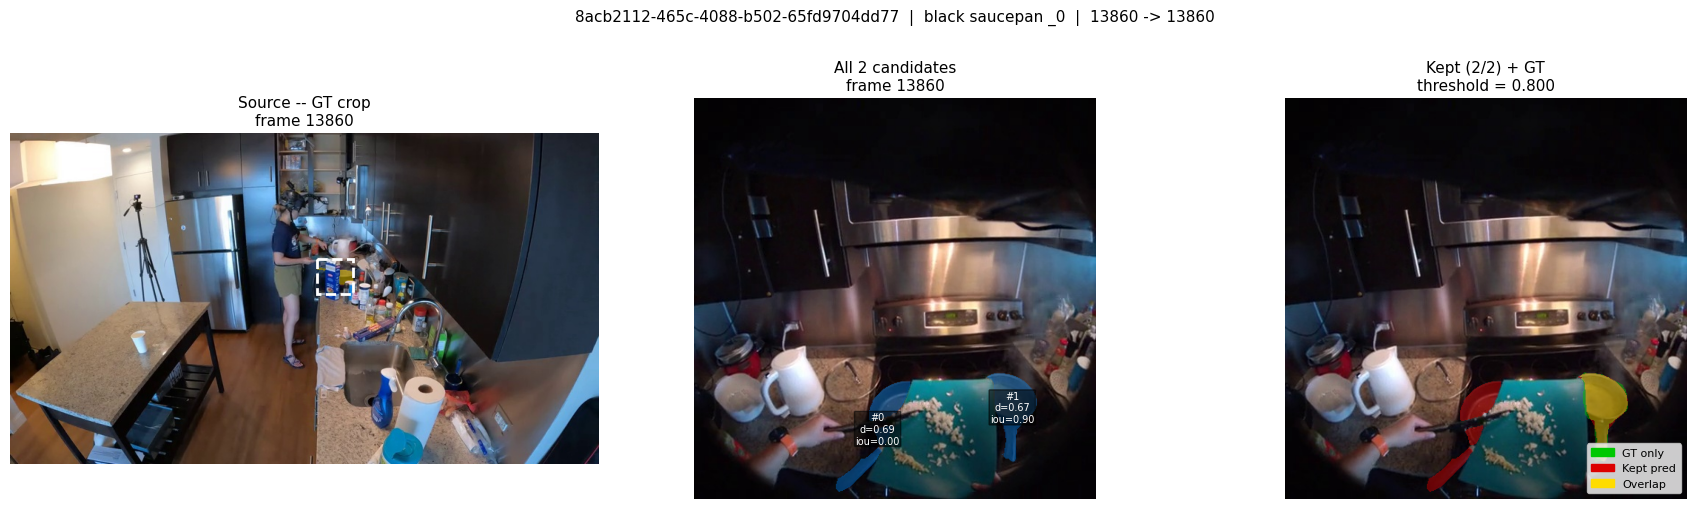

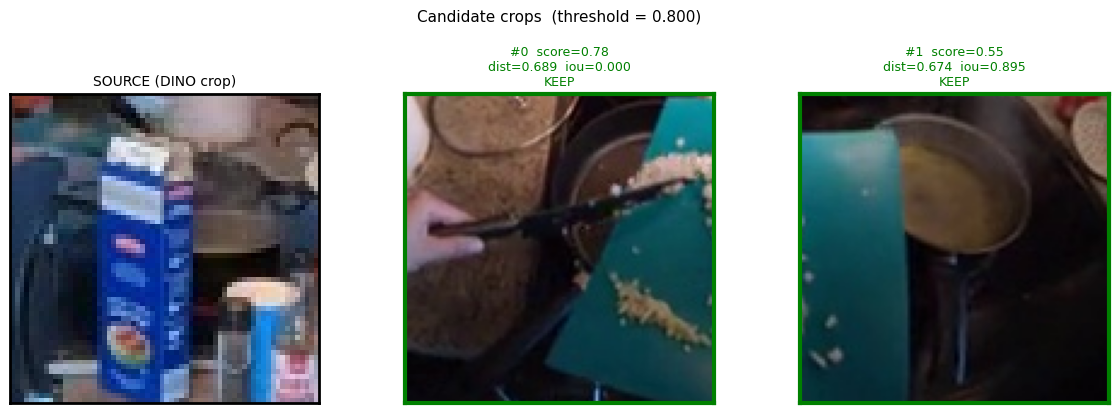

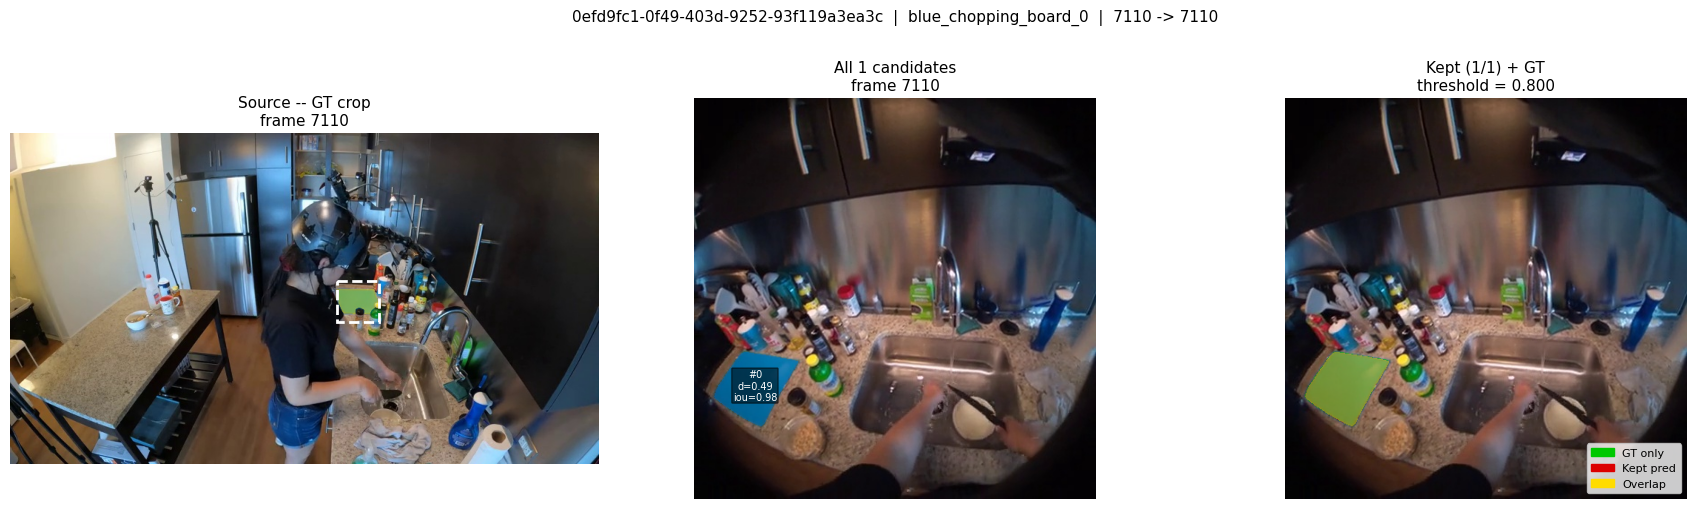

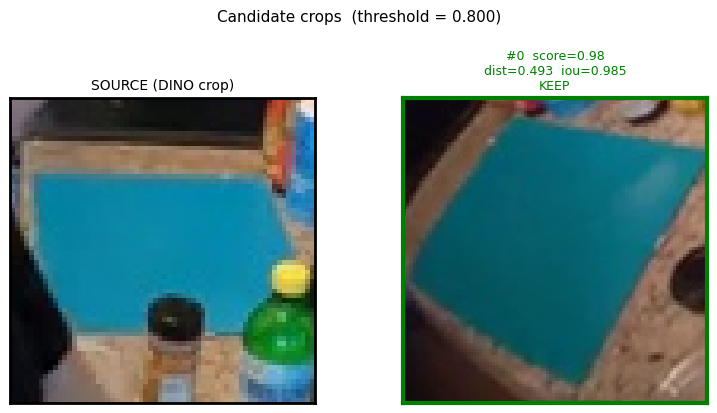

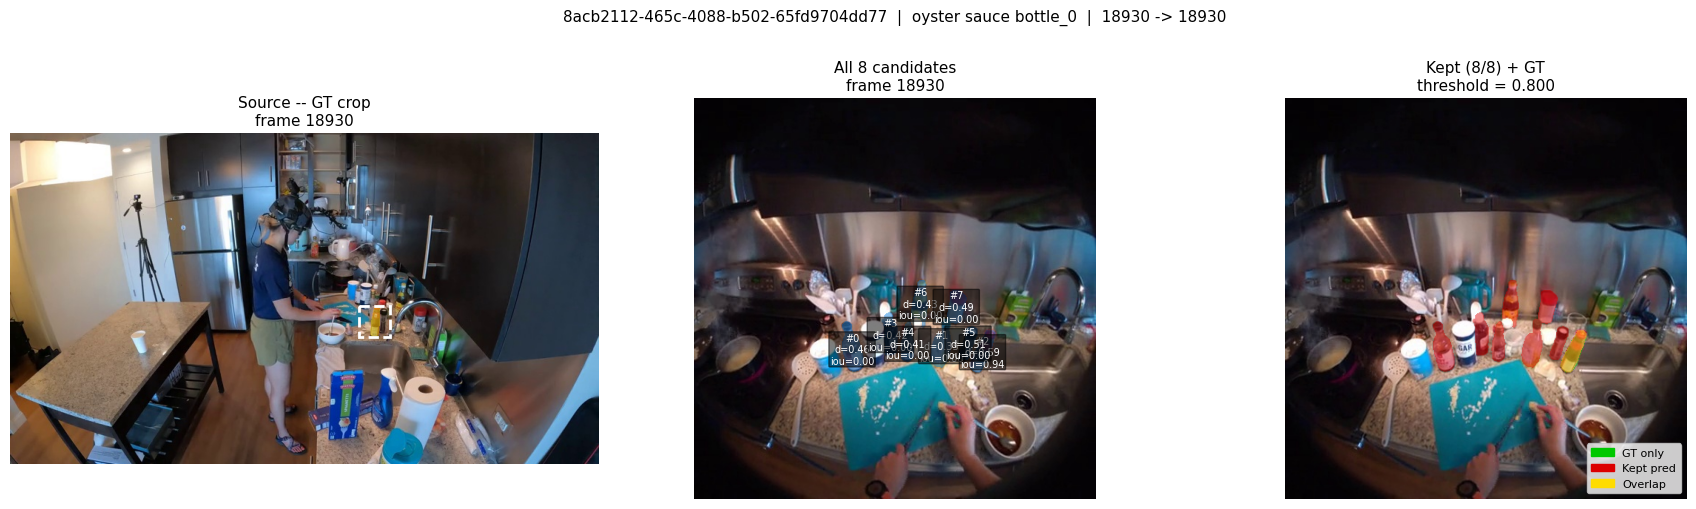

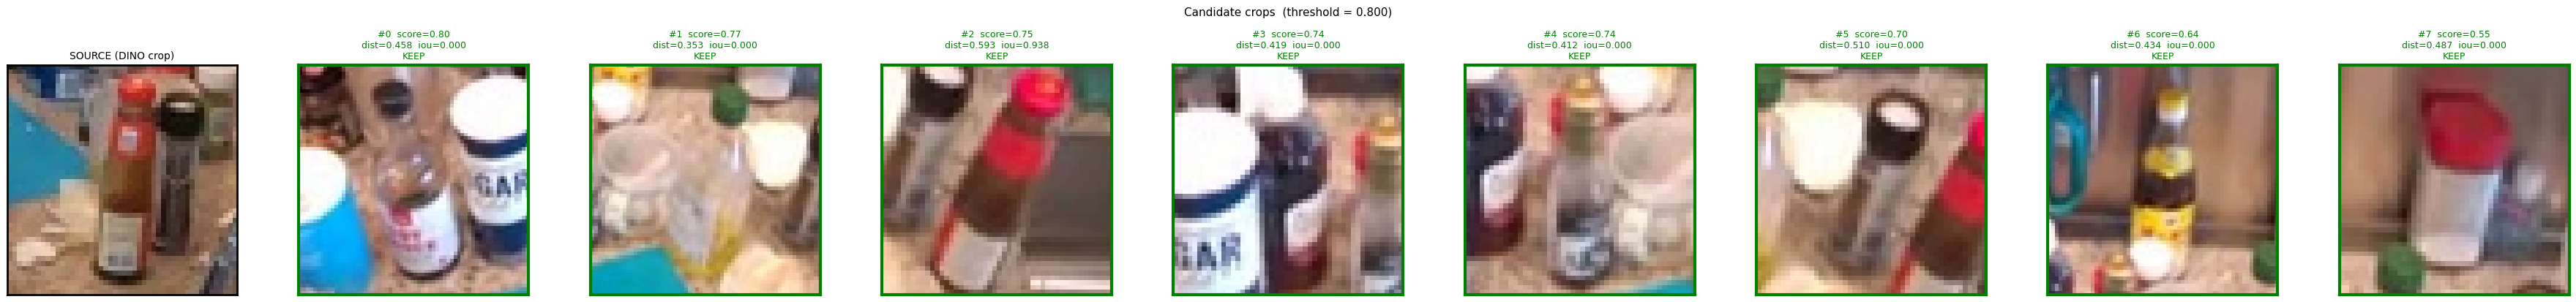

In [58]:
for idx, r in enumerate(results):
    if r is None or idx % VIS_STRIDE != 0:
        continue

    fig = plot_sample(
        src_rgb=r["src_rgb"],
        src_gt_mask=r["src_gt_mask"],
        dst_rgb=r["dst_rgb"],
        dst_gt_mask=r["dst_gt_mask"],
        cand_masks=r["cand_masks"],
        distances=r["distances"],
        gt_ious=r["gt_ious"],
        threshold=COSINE_THRESHOLD,
        take_uid=r["take_uid"],
        obj_name=r["obj_name"],
        src_frame=r["src_frame"],
        dst_frame=r["dst_frame"],
    )
    plt.show()

    fig2 = render_candidate_grid(
        src_rgb=r['src_rgb'],
        src_gt_mask=r['src_gt_mask'],
        dst_rgb=r["dst_rgb"],
        cand_masks=r["cand_masks"],
        cand_scores=r["pred_scores"],
        distances=r["distances"],
        gt_ious=r["gt_ious"],
        threshold=COSINE_THRESHOLD,
    )
    plt.show()

## 6. Summary Statistics

Metric                                                 Value
──────────────────────────────────────────────────────────────
Mean candidates before filtering                         9.5
Mean candidates after filtering                          2.0
% candidates filtered                                  78.9%
False negative rate (GT-best candidate dropped)       100.0%
Mean GT IoU of best kept candidate                     0.000
Mean GT IoU of best dropped candidate                  0.001


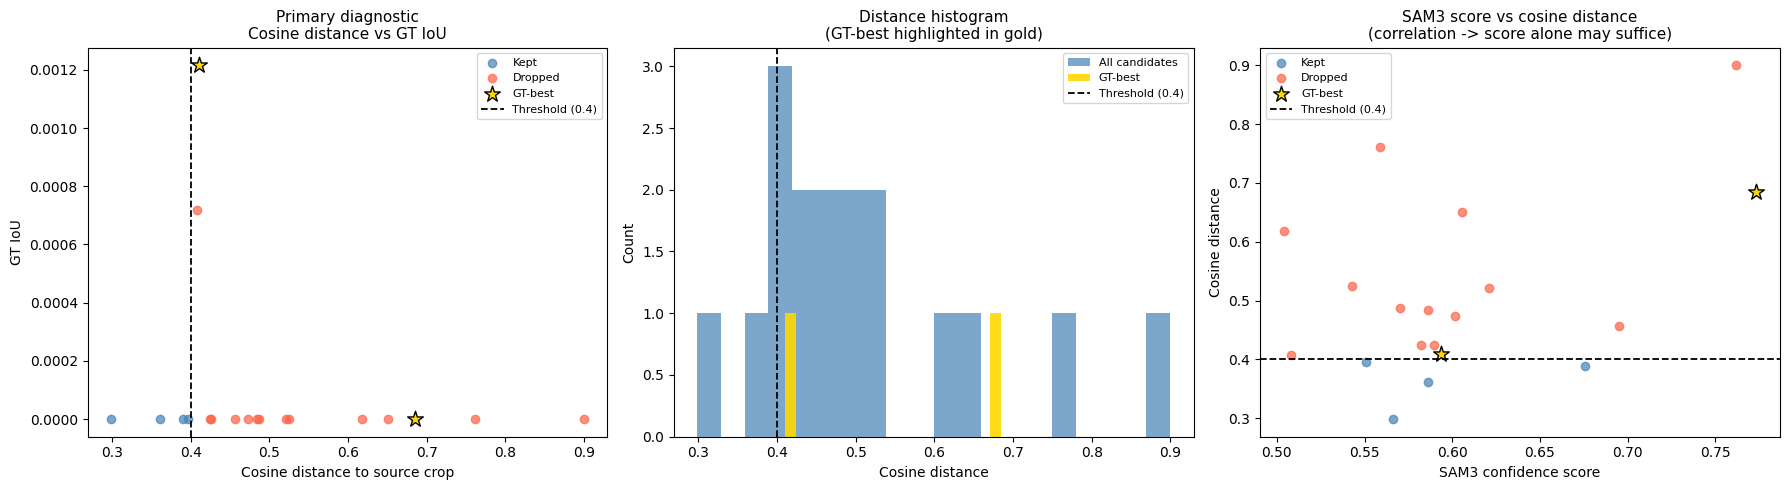

In [20]:
valid = [r for r in results if r is not None]

if not valid:
    print("No valid results to summarise.")
else:
    mean_before  = np.mean([r["n_before"]          for r in valid])
    mean_after   = np.mean([r["n_after"]            for r in valid])
    pct_filtered = (1 - mean_after / mean_before) * 100 if mean_before > 0 else 0.0
    fn_rate      = np.mean([r["false_negative"]     for r in valid]) * 100
    mean_kept    = np.mean([r["best_kept_iou"]      for r in valid])
    mean_dropped = np.mean([r["best_dropped_iou"]   for r in valid])

    print(f"{'Metric':<50}  {'Value':>8}")
    print("\u2500" * 62)
    print(f"{'Mean candidates before filtering':<50}  {mean_before:>8.1f}")
    print(f"{'Mean candidates after filtering':<50}  {mean_after:>8.1f}")
    print(f"{'% candidates filtered':<50}  {pct_filtered:>7.1f}%")
    print(f"{'False negative rate (GT-best candidate dropped)':<50}  {fn_rate:>7.1f}%")
    print(f"{'Mean GT IoU of best kept candidate':<50}  {mean_kept:>8.3f}")
    print(f"{'Mean GT IoU of best dropped candidate':<50}  {mean_dropped:>8.3f}")

    # Flatten all candidate data across samples
    all_dists, all_ious, all_kept_flags, all_gt_best_flags, all_scores = [], [], [], [], []
    for r in valid:
        best_gt = int(np.argmax(r["gt_ious"]))
        for i, (d, iou) in enumerate(zip(r["distances"], r["gt_ious"])):
            all_dists.append(d)
            all_ious.append(iou)
            all_kept_flags.append(i in r["kept_idx"])
            all_gt_best_flags.append(i == best_gt)
            sc = r["pred_scores"][i] if i < len(r["pred_scores"]) else 0.0
            all_scores.append(float(sc))

    all_dists      = np.array(all_dists)
    all_ious       = np.array(all_ious)
    all_kept_flags = np.array(all_kept_flags)
    all_gt_best    = np.array(all_gt_best_flags)
    all_scores     = np.array(all_scores)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # -- Primary: cosine distance vs GT IoU -----------------------------------
    ax = axes[0]
    ax.scatter(
        all_dists[ all_kept_flags & ~all_gt_best], all_ious[ all_kept_flags & ~all_gt_best],
        c="steelblue", alpha=0.7, label="Kept", zorder=2,
    )
    ax.scatter(
        all_dists[~all_kept_flags & ~all_gt_best], all_ious[~all_kept_flags & ~all_gt_best],
        c="tomato", alpha=0.7, label="Dropped", zorder=2,
    )
    ax.scatter(
        all_dists[all_gt_best], all_ious[all_gt_best],
        c="gold", edgecolors="black", s=140, marker="*", label="GT-best", zorder=3,
    )
    ax.axvline(COSINE_THRESHOLD, color="black", linestyle="--", linewidth=1.3,
               label=f"Threshold ({COSINE_THRESHOLD})")
    ax.set_xlabel("Cosine distance to source crop")
    ax.set_ylabel("GT IoU")
    ax.set_title("Primary diagnostic\nCosine distance vs GT IoU")
    ax.legend(fontsize=8)

    # -- Distance histogram ---------------------------------------------------
    ax = axes[1]
    ax.hist(all_dists[~all_gt_best], bins=20, color="steelblue", alpha=0.7, label="All candidates")
    ax.hist(all_dists[ all_gt_best], bins=20, color="gold",      alpha=0.9, label="GT-best")
    ax.axvline(COSINE_THRESHOLD, color="black", linestyle="--", linewidth=1.3,
               label=f"Threshold ({COSINE_THRESHOLD})")
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Count")
    ax.set_title("Distance histogram\n(GT-best highlighted in gold)")
    ax.legend(fontsize=8)

    # -- SAM3 score vs cosine distance ----------------------------------------
    ax = axes[2]
    ax.scatter(
        all_scores[ all_kept_flags & ~all_gt_best], all_dists[ all_kept_flags & ~all_gt_best],
        c="steelblue", alpha=0.7, label="Kept",
    )
    ax.scatter(
        all_scores[~all_kept_flags & ~all_gt_best], all_dists[~all_kept_flags & ~all_gt_best],
        c="tomato", alpha=0.7, label="Dropped",
    )
    ax.scatter(
        all_scores[all_gt_best], all_dists[all_gt_best],
        c="gold", edgecolors="black", s=140, marker="*", label="GT-best",
    )
    ax.axhline(COSINE_THRESHOLD, color="black", linestyle="--", linewidth=1.3,
               label=f"Threshold ({COSINE_THRESHOLD})")
    ax.set_xlabel("SAM3 confidence score")
    ax.set_ylabel("Cosine distance")
    ax.set_title("SAM3 score vs cosine distance\n(correlation -> score alone may suffice)")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 7. Optional: Single Agent Run  *(illustrative — skip if Ollama unavailable)*

Runs `agent_inference()` on the sample with the **largest cosine distance spread** — once without filtering (baseline) and once with the inline DINOv3 filter. Shows final outputs side by side and prints wall-clock time.

This is **not** part of the main analysis. Its purpose is to give intuition for what the filter does at the agent level before modifying `agent_core.py`.

**Requires**: Ollama running locally or cloud access. Edit `OLLAMA_HOST`, `OLLAMA_MODEL`, `OLLAMA_API_KEY` below.

In [ ]:
import time
from ollama import Client
from sam3.agent.agent_core import agent_inference

# -- Ollama config ------------------------------------------------------------
OLLAMA_HOST    = "http://localhost:11434"  # <- or "https://ollama.com"
OLLAMA_MODEL   = "qwen3-vl:235b-cloud"    # <- VLM model name
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY", "ollama")

# -- Pick sample with largest cosine distance spread --------------------------
_valid_for_agent = [r for r in results if r is not None and r["n_before"] >= 2]
assert _valid_for_agent, "No valid results with >=2 candidates."

_best = max(_valid_for_agent, key=lambda r: max(r["distances"]) - min(r["distances"]))
print(f"Selected sample #{_best['idx']} -- take: {_best['take_uid']} | "
      f"object: {_best['obj_name']} | {_best['direction']}")
print(f"Distance spread: {min(_best['distances']):.3f} - {max(_best['distances']):.3f}")

# -- Ollama send_generate_request ---------------------------------------------
def _parse_messages(messages):
    system_prompt, prompt, images_b64 = None, "", []
    for m in messages:
        if m.get("role") == "system":
            system_prompt = m.get("content", "")
        elif m.get("role") == "user":
            content = m.get("content", "")
            if isinstance(content, list):
                for part in content:
                    if isinstance(part, dict):
                        if part.get("type") == "text":
                            prompt += part.get("text", "")
                        elif part.get("type") == "image_url":
                            url = part.get("image_url", {}).get("url", "")
                            if "," in url:
                                images_b64.append(url.split(",", 1)[-1])
            else:
                prompt = str(content)
    return system_prompt, prompt, images_b64

_vlm_client = Client(
    host=OLLAMA_HOST,
    headers={"Authorization": f"Bearer {OLLAMA_API_KEY}"},
)

def _send_generate_request(messages):
    """Ollama wrapper matching the interface expected by agent_inference."""
    system_prompt, prompt, images_b64 = _parse_messages(messages)
    msgs = []
    if system_prompt:
        msgs.append({"role": "system", "content": system_prompt})
    msgs.append({"role": "user", "content": prompt, "images": images_b64 or []})
    text = ""
    for part in _vlm_client.chat(
        model=OLLAMA_MODEL, messages=msgs, stream=True,
        options={"temperature": 0, "seed": 777, "num_predict": 2048},
    ):
        text += part.message.content or ""
    return text.strip()

_dst_path = os.path.join(
    DATA_DIR, _best["take_uid"], _best["dst_cam"], f"{_best['dst_frame']}.jpg"
)
_agent_out = os.path.join(_tmp_dir, "agent_runs")
os.makedirs(_agent_out, exist_ok=True)

# -- Baseline run -------------------------------------------------------------
print("\n-- Baseline run (no filter) --")
_t0 = time.time()
_baseline_hist, _baseline_out, _ = agent_inference(
    img_path=_dst_path,
    initial_text_prompt=OBJECT_DESCRIPTIONS[_best["idx"]],
    send_generate_request=_send_generate_request,
    call_sam_service=call_sam_service_base,
    output_dir=os.path.join(_agent_out, "baseline"),
    debug=False,
)
_baseline_time = time.time() - _t0
print(f"  Wall time : {_baseline_time:.1f} s")
print(f"  Turns     : {sum(1 for m in _baseline_hist if m.get('role') == 'assistant')}")

# -- Aligned run (inline filter) ----------------------------------------------
_src_emb_agent = embed_crop(
    make_dino_crop(_best["src_rgb"], _best["src_gt_mask"]), dino_model, device
)
_H_d, _W_d = _best["dst_rgb"].shape[:2]

def _call_sam_aligned(image_path, text_prompt, output_folder_path):
    """call_sam_service_base + inline DINOv3 filter applied to the JSON output."""
    _json_path = call_sam_service_base(
        image_path=image_path,
        text_prompt=text_prompt,
        output_folder_path=output_folder_path,
    )
    with open(_json_path) as _f:
        _data = json.load(_f)

    _orig_h = _data.get("orig_img_h", _H_d)
    _orig_w = _data.get("orig_img_w", _W_d)
    _kept_masks, _kept_scores, _kept_boxes = [], [], []

    for _rle, _sc, _bx in zip(
        _data.get("pred_masks", []),
        _data.get("pred_scores", []),
        _data.get("pred_boxes", []),
    ):
        _m = decode_mask(_rle, _orig_h, _orig_w)
        if _m.shape != (_H_d, _W_d):
            _m = np.array(
                Image.fromarray(_m.astype(np.uint8) * 255).resize((_W_d, _H_d), Image.NEAREST)
            ).astype(bool)
        _dist = cosine_distance(_src_emb_agent, embed_crop(make_dino_crop(_best["dst_rgb"], _m), dino_model, device)) if _m.any() else 2.0
        if _dist <= COSINE_THRESHOLD:
            _kept_masks.append(_rle)
            _kept_scores.append(_sc)
            _kept_boxes.append(_bx)

    print(f"    [filter] kept {len(_kept_masks)} / {len(_data.get('pred_masks', []))} candidates")
    _data["pred_masks"]  = _kept_masks
    _data["pred_scores"] = _kept_scores
    _data["pred_boxes"]  = _kept_boxes
    with open(_json_path, "w") as _f:
        json.dump(_data, _f)
    return _json_path

print("\n-- Aligned run (DINOv3 filter) --")
_t0 = time.time()
_aligned_hist, _aligned_out, _ = agent_inference(
    img_path=_dst_path,
    initial_text_prompt=OBJECT_DESCRIPTIONS[_best["idx"]],
    send_generate_request=_send_generate_request,
    call_sam_service=_call_sam_aligned,
    output_dir=os.path.join(_agent_out, "aligned"),
    debug=False,
)
_aligned_time = time.time() - _t0
print(f"  Wall time : {_aligned_time:.1f} s  ({_aligned_time - _baseline_time:+.1f} s vs baseline)")
print(f"  Turns     : {sum(1 for m in _aligned_hist if m.get('role') == 'assistant')}")

# -- Side-by-side output visualisation ----------------------------------------
def _union_masks(output_dict, H, W):
    union = np.zeros((H, W), dtype=bool)
    for _rle in output_dict.get("pred_masks", []):
        _m = decode_mask(_rle, output_dict.get("orig_img_h", H), output_dict.get("orig_img_w", W))
        if _m.shape != (H, W):
            _m = np.array(Image.fromarray(_m.astype(np.uint8) * 255).resize((W, H), Image.NEAREST)).astype(bool)
        union |= _m
    return union

_baseline_union = _union_masks(_baseline_out, _H_d, _W_d)
_aligned_union  = _union_masks(_aligned_out,  _H_d, _W_d)

_fig, _axes = plt.subplots(1, 2, figsize=(14, 5))
_axes[0].imshow(render_overlay(_best["dst_rgb"], _baseline_union, _best["dst_gt_mask"]))
_axes[0].set_title(
    f"Baseline (no filter)\nIoU = {compute_iou(_baseline_union, _best['dst_gt_mask']):.3f}  |  {_baseline_time:.1f} s"
)
_axes[0].axis("off")
_axes[1].imshow(render_overlay(_best["dst_rgb"], _aligned_union, _best["dst_gt_mask"]))
_axes[1].set_title(
    f"Aligned (threshold = {COSINE_THRESHOLD})\nIoU = {compute_iou(_aligned_union, _best['dst_gt_mask']):.3f}  |  {_aligned_time:.1f} s"
)
_axes[1].axis("off")
for _ax in _axes:
    _ax.legend(handles=[
        mpatches.Patch(color=(0, 200/255, 0),  label="GT only"),
        mpatches.Patch(color=(220/255, 0, 0),  label="Pred only"),
        mpatches.Patch(color=(1.0, 220/255, 0), label="Overlap"),
    ], loc="lower right", fontsize=8)
_fig.suptitle(
    f"Illustrative agent run -- {_best['take_uid']} | {_best['obj_name']}", y=1.01
)
plt.tight_layout()
plt.show()

: 

## 8. Cleanup

In [ ]:
shutil.rmtree(_tmp_dir, ignore_errors=True)
print(f"Removed temp dir: {_tmp_dir}")

for _var in ["dino_model", "_sam3_model", "sam3_processor"]:
    if _var in dir():
        del globals()[_var]

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()
print("Done.")

: 